# 27类分析

C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 36149 (\N{CJK UNIFIED IDEOGRAPH-8D35}) missing from current font.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from current font.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from current font.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from current font.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from current font.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_22464\1199777919.py:47: UserWarning: Glyph 27743 (\N{CJK UNIFIED IDEOGRAPH-6C5F}) missing fr

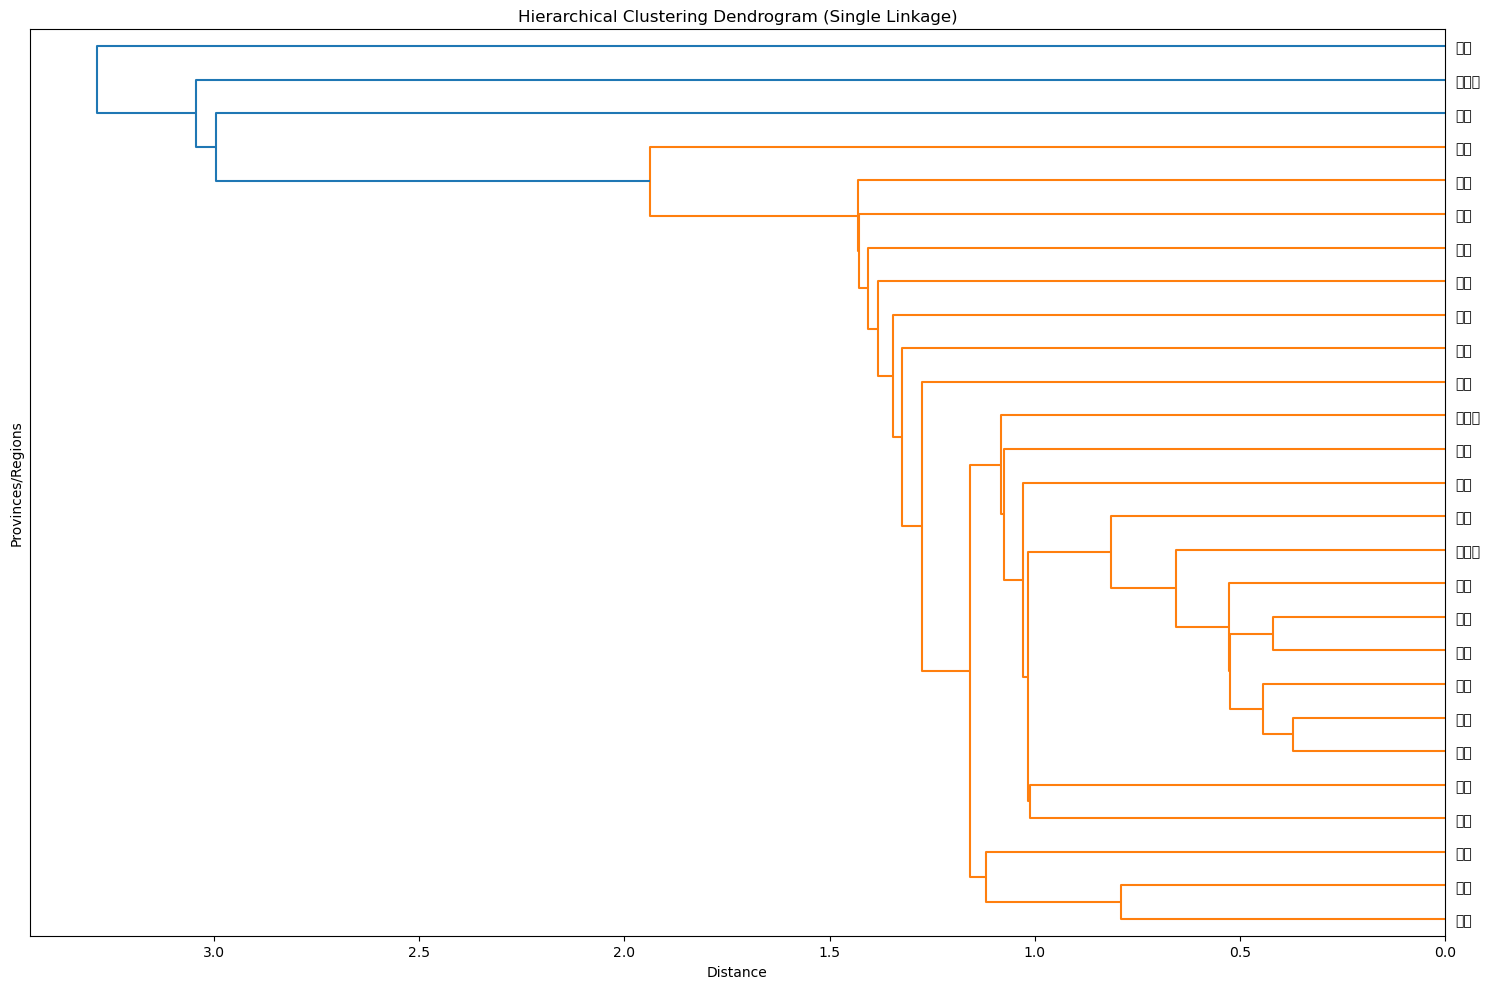

In [2]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np



# Load the data
df = pd.read_csv(r'D:\Mathematical Modeling\Mathematical-Modeling\大二下-数学建模课程\作业6\data10_1.csv')

# Extract the province/region names and the numerical data
provinces = df.iloc[:, 0].tolist()
data = df.iloc[:, 1:].values

# (1) Data Standardization (Z-score standardization)
# The problem description mentions using (aj - mu_j) / s_j, where mu_j and s_j are sample mean and sample standard deviation.
# This is exactly Z-score standardization.

# Calculate mean and standard deviation for each column (feature)
mu = np.mean(data, axis=0)
s = np.std(data, axis=0)

# Standardize the data
data_standardized = (data - mu) / s

# (2) Calculate Euclidean distance between 27 sample points
distance_matrix = pdist(data_standardized, metric='euclidean')
distance_square_matrix = squareform(distance_matrix)

# (3) & (4) Hierarchical Clustering using Single Linkage (shortest distance method)
# The problem states to use the shortest distance method to measure distance between classes.
# This corresponds to 'single' linkage in scipy's linkage function.

linked = linkage(data_standardized, method='single')

# (6) Plot the dendrogram
plt.figure(figsize=(15, 10))
dendrogram(linked,
           orientation='left',
           labels=provinces,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Distance')
plt.ylabel('Provinces/Regions')
plt.tight_layout()
plt.savefig('dendrogram.png')
plt.show()

# Optional: Print the distance matrix (first few rows/cols for brevity)
# print("Standardized Data:\n", data_standardized)
# print("\nDistance Matrix (Euclidean):\n", distance_square_matrix)
# print("\nLinkage Matrix:\n", linked)